In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.dummy import DummyRegressor

In [22]:
sales = pd.read_csv(
    "inventory_optimization/data/processed/sales_clean.csv"
)

sales["date"] = pd.to_datetime(
    sales["date"]
)

sales = sales.sort_values(
    ["sku_id", "date"]
)

In [23]:
sales["lag_1_units"] = (
    sales.groupby("sku_id")["units_sold"]
    .shift(1)
)

sales["lag_7_units"] = (
    sales.groupby("sku_id")["units_sold"]
    .shift(7)
)

sales["lag_30_units"] = (
    sales.groupby("sku_id")["units_sold"]
    .shift(30)
)

In [24]:
sales["rolling_mean_7"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(
        lambda x:
        x.shift(1).rolling(7).mean()
    )
)

sales["rolling_mean_14"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(
        lambda x:
        x.shift(1).rolling(14).mean()
    )
)

sales["rolling_std_7"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(
        lambda x:
        x.shift(1).rolling(7).std()
    )
)

In [25]:
sales["target_7d"] = (
    sales.groupby("sku_id")["units_sold"]
    .shift(-7)
)

In [26]:
model_df = sales.dropna().copy()

model_df.shape

(13160, 34)

In [27]:
model_df["baseline_pred"] = (
    model_df["lag_7_units"]
)

In [28]:
cutoff_date = model_df["date"].quantile(
    0.80
)

train = model_df[
    model_df["date"] <= cutoff_date
]

test = model_df[
    model_df["date"] > cutoff_date
]

In [29]:
print(train.shape)
print(test.shape)

print(train["date"].min())
print(train["date"].max())

print(test["date"].min())
print(test["date"].max())

(10560, 35)
(2600, 35)
2024-01-31 00:00:00
2024-10-20 00:00:00
2024-10-21 00:00:00
2024-12-24 00:00:00


In [30]:
y_true = test["target_7d"]

y_pred = test["baseline_pred"]

mae = mean_absolute_error(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

r2 = r2_score(
    y_true,
    y_pred
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 6.22
RMSE : 8.21
R²   : -0.1984


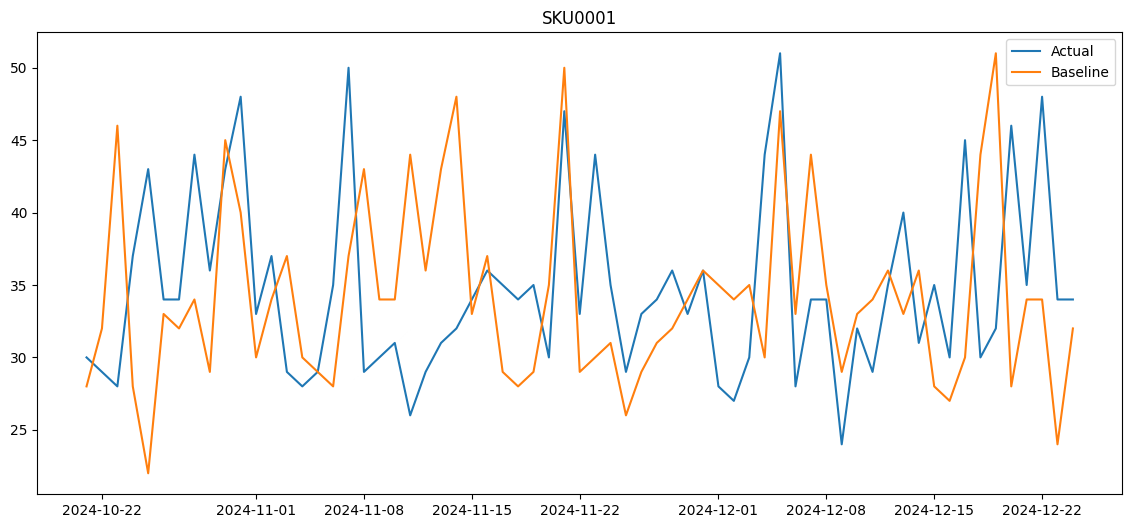

In [33]:
sample_sku = (
    test["sku_id"]
    .value_counts()
    .index[0]
)

plot_df = test[
    test["sku_id"] == sample_sku
]

plt.figure(figsize=(14,6))

plt.plot(
    plot_df["date"],
    plot_df["target_7d"],
    label="Actual"
)

plt.plot(
    plot_df["date"],
    plot_df["baseline_pred"],
    label="Baseline"
)

plt.legend()

plt.title(sample_sku)

plt.show()

Baseline Forecast Summary

Forecast Horizon: 7 Days

Method:
Demand after 7 days is assumed to be equal to demand observed 7 days ago.

Metrics:
MAE = 6.22
RMSE = 8.12
R² = -0.1924

Observation:
The baseline captures the general trend but struggles with sudden demand spikes.

Next Step:
Compare against Random Forest and XGBoost models.